In [1]:
# Import Library

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [2]:
# Load Dataset Hasil Preprocessing

df = pd.read_csv("dataset_preprocessing.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361,20
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058,20
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066,20
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048,20
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373,20


In [3]:
# Feature dan Target

X = df.drop(columns=['label'])
y = df['label']

In [4]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1760, 7)
(440, 7)


# Model Training

Tahap ini bertujuan melatih model machine learning menggunakan algoritma Random Forest Classifier untuk melakukan klasifikasi jenis tanaman berdasarkan fitur tanah dan lingkungan.

In [5]:
# Training Model

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Prediksi

y_pred = model.predict(X_test)

In [7]:
# Accuracy

acc = accuracy_score(y_test, y_pred)

print("Accuracy :", acc)

Accuracy : 0.9954545454545455


# Evaluasi Model

Evaluasi dilakukan menggunakan Accuracy Score, Classification Report, dan Confusion Matrix untuk mengetahui performa model pada data uji.

In [8]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

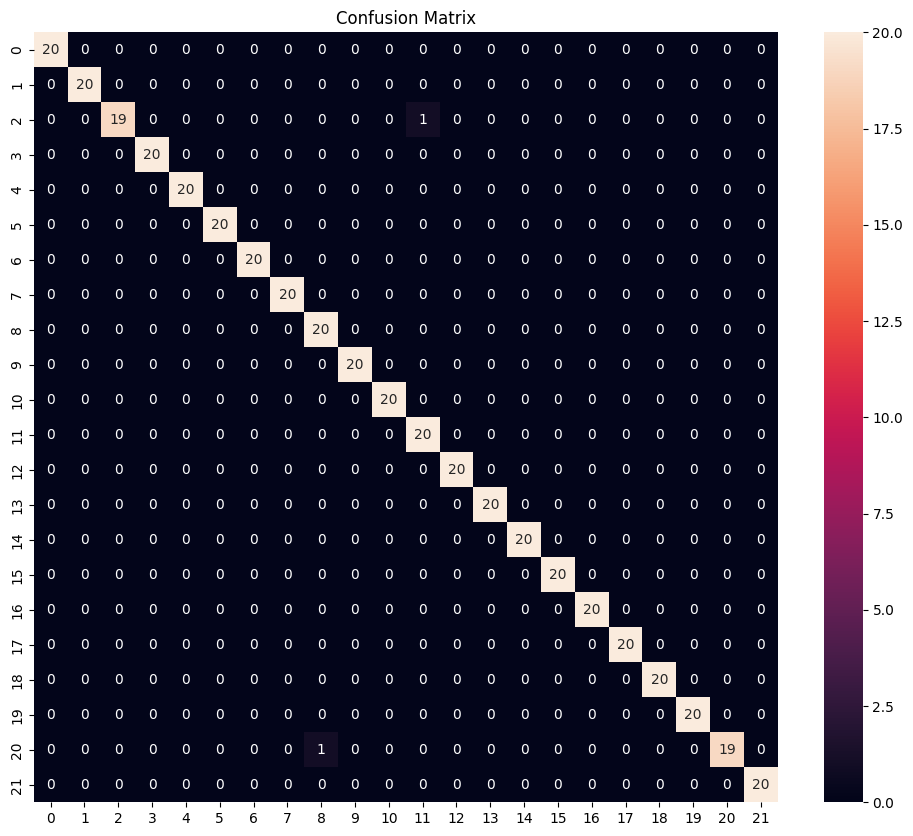

In [9]:
# Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [10]:
# Simpan Model

joblib.dump(
    model,
    "crop_model.pkl"
)

print("Model berhasil disimpan")

Model berhasil disimpan


# Kesimpulan Modelling

Model Random Forest berhasil dilatih menggunakan dataset hasil preprocessing.

Hasil evaluasi menunjukkan nilai akurasi sebesar 99.54% pada data uji.

Model kemudian disimpan dalam format .pkl untuk digunakan pada tahap deployment dan monitoring.